# Temporal-Difference Learning

TD learning is a combination of Monte Carlo ideas and dynamic programming (DP) ideas. Like Monte Carlo methods, TD methods can learn directly from raw experience without a model of the environment's dynamics. Like DP, TD methods udpate estimates based in part on other learned estimates, without waiting for a final outcome (they boostrap).

## TD Prediction

Both TD and Monte Carlo method use experience to solve the prediction problem. Given some experience followin a policy $\pi$, both methods update their estimate $V$ of $v_{\pi}$ for the nonterminal states $S_t$ occurring in that experience. Monte Carlo methods wait until the return following the visit is known, then use that return as a target for $V(S_t)$. 

Whereas Monte Carlo methods must wait until the end of the episode to determine the increment to $V(S_t)$, TD methods need to wait only until the next time step. At time $t + 1$ they immediately form a target and make a useful update using the observed reward $R_{t+1}$ and the estimate $V(S_{t+1})$. The simplest TD method makes the update:

$$
V(S_t) \leftarrow V(S_t) + \alpha [R_{t+1} + \gamma V(S_{t+1}) - V(S_t)]
$$

immediately on transition to $S_{t+1}$ and receiving $R_{t+1}$. In effect, the target for Monte Carlo update is $G_t$, whereas the target for the TD update is $R_{t+1} + \gamma V(S_{t+1})$. This TD method is called *TD(0)*, or *one-step TD*, because it is a special case of the *TD($\lambda$)* and *n-step* TD methods.

**Tabular TD(0) for estimating $v_{\pi}$**

```text
Input: the policy pi to be evaluated
Algorithm parameter: step sice alpha = (0, 1]
Initialize V(s), for all states in S, arbitrarily except that V(terminal) = 0

Loop for each episode:
    Initialize S
    Loop for each step of episode:
    A <- action given by pi for S
    Take action A, observe R, S'
    V(s) <- V(S) + alpha[R + gamma V(S') - V(S)]
    S <- S'
until S is terminal

Because TD(0) bases its update in part on an existing estimate, we say that it is a *bootstraping* method, like DP.

We refere to TD and Monte Carlo updates as *sample updates* because they involve looking ahead to a sample *successor* state (or state-action pair). *Sample* updates differ from the *expected* updates of Dp methods in that they are based on a single sample successor rather than on a complete distribution of all possible successors.

The quantity in brackets in the TD(0) update is a sort of error, measuring the difference between the estimated value of $S_t$ and the better estimate $R_{t+1} + \gamma V(S_{t+1})$. This quantity, called the *TD error* arises in various forms throughout reinforcement learning:

$$
\delta_t \dot{=} R_{t+1} + \gamma V(S_{t+1}) - V(S_t)
$$

## Advantages of TD Prediction Methods

TD methods have an advantage over DP methods in that they do not require a model of the environment, of its reward and ntext-state probability distributions. An advantage over Monte Carlo methods is that they are naturally implemented in an online, fully incremental fashion without waiting to finish an episode.

## Sarsa: On-policy TD Control

For an on-policy method we must estimate $q_{\pi}(s, a)$ for the current behavior policy $\pi$ and for all states $s$ and actions $a$. Now we will consider transitions from state-action pair to state-action pair:

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)]
$$

This update is done after every transition from a nonterminal state $S_t$. If $S_{t+1}$ is terminal, then $Q(S_{t+1}, A_{t+1})$ is defined as zero. This rule uses every element of the quintuple events, ($S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$. This quintuple gives the name for the algorithm *SARSA*.

**Sarsa (on-policy TD control) for estimating $Q \approx q_*$**

```text
Algorithm parameters: step size alpha in (0, 1], small eps > 0
Initialize Q(s, a), for all s in S, a in A(s), arbitrarily except that Q(terminal, ) = 0

Loop for each episode:
    Initialize S
    Choose A from S using policy derived from Q(e.g. eps-greedy)
    Loop for each step of episode:
        Take action A, observe R, S'
        Choose A' from S' using policy derived from Q(e.g. eps-greedy)
        Q(S, A) <- Q(S, A) + alpha [R + gamma Q(S', A') - Q(S, A)]
        S <- S'; A <- A';
    until S is terminal

### Example: Windy Gridworld

In [32]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from IPython import display


class WindyGridWorld(gym.Env):

    nrows = 7
    ncols = 10
    start = (3, 0)
    goal = (3, 7)
    wind = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]

    maping = {
        0: (0, 1), # Right
        1: (1, 0), # Down
        2: (0, -1), # Left
        3: (-1, 0) # Up
    }

    def __init__(self):
        self.observation_space = gym.spaces.MultiDiscrete([self.nrows, self.ncols])
        self.action_space = gym.spaces.Discrete(4)
        self.state = None

        self.fig = None
        self.ax = None

    def step(self, action):
        diff = self.maping[action]
        state = (self.state[0] + diff[0] - self.wind[self.state[1]], self.state[1] + diff[1])
        
        self.state = (np.clip(state[0], 0, self.nrows-1), np.clip(state[1], 0, self.ncols-1))

        if self.state == self.goal:
            return self.state, -1.0, True, {}

        return self.state, -1.0, False, {}

    def reset(self, state=None):
        if state is None:
            self.state = self.start
        else:
            self.state = state

        return self.state
    
    def render(self, prev_state, state):
        if self.ax is None:
            self.fig, self.ax = plt.subplots()

        data = np.zeros((self.nrows, self.ncols))
        self.ax.imshow(data, cmap='Greys', alpha=0.1)

        self.ax.set_xticks(np.arange(self.ncols))
        self.ax.set_yticks(np.arange(self.nrows))

        self.ax.set_xticks(np.arange(-.5, self.ncols, 1), minor=True)
        self.ax.set_yticks(np.arange(-.5, self.nrows, 1), minor=True)
        self.ax.grid(which='minor', color='black', linestyle='-', linewidth=1)

        self.ax.annotate("", xy=(state[1], state[0]),         # Arrow tip
                             xytext=(prev_state[1], prev_state[0]), # Arrow tail
                             arrowprops=dict(
                             arrowstyle="->", 
                             color="red", 
                             lw=2
                             # shrinkA=5, shrinkB=5 # Keeps arrow inside the cell
        ))

        self.ax.tick_params(which='both',
                    bottom=False,
                    left=False,
                    labelbottom=False,
                    labelleft=False
        )

        self.ax.text(self.start[1], self.start[0], 'S', va='center', ha='center', fontsize=20, color='blue')
        self.ax.text(self.goal[1], self.goal[0], 'G', va='center', ha='center', fontsize=20, color='blue')

        self.ax.set_title("Agent Exploration Path")

        display.display(self.fig)

In [36]:
def policy(env, q, state, eps):
    n_actions = env.action_space.n
    prob = np.random.rand()

    if prob > eps:
        # Select best action
        best_action = np.argmax(q[state[0], state[1], :])
        return best_action

    # Selects a random action
    return np.random.choice(n_actions)

def sarsa(env, eps = 0.1, alpha = 0.5, gamma=1.0, num_episodes=500, render=False):

    size = env.observation_space.nvec.tolist()
    size.append(env.action_space.n)

    q = np.zeros(size)
    episode = 0
    for _ in tqdm(range(num_episodes)):
        obs = env.reset()
        done = False

        while not done: 
            action = policy(env, q, obs, eps)

            next_obs, reward, done, info = env.step(action)
            next_action = policy(env, q, next_obs, eps)

            td_error = reward + gamma*q[next_obs[0], next_obs[1], next_action] - q[obs[0], obs[1], action]
            q[obs[0], obs[1], action] = q[obs[0], obs[1], action] + alpha*td_error

            if render:
                env.render(obs, next_obs)

            obs = next_obs
            action = next_action

        episode+=1

    pi = np.argmax(q, axis=2)

    return q, pi

def plot_episode(env, pi):

    size = env.observation_space.nvec.tolist()
    size.append(env.action_space.n)

    obs = env.reset()
    done = False
        
    while not done: 
        action = pi[obs[0], obs[1]]

        next_obs, reward, done, info = env.step(action)

        env.render(obs, next_obs)

        obs = next_obs

In [37]:
env = WindyGridWorld()
q, pi = sarsa(env, num_episodes=1500)

100%|██████████| 1500/1500 [00:00<00:00, 5113.88it/s]


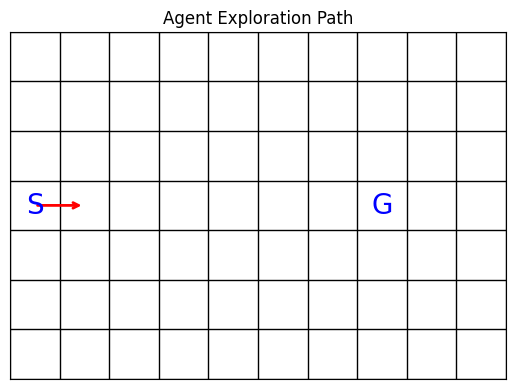

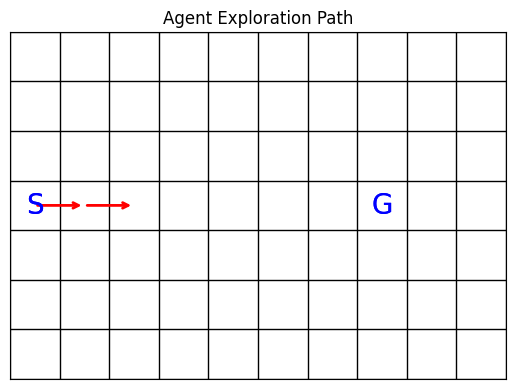

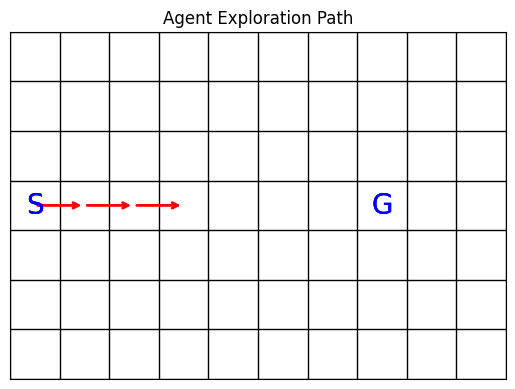

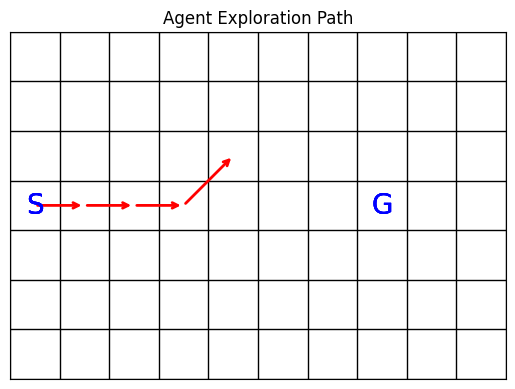

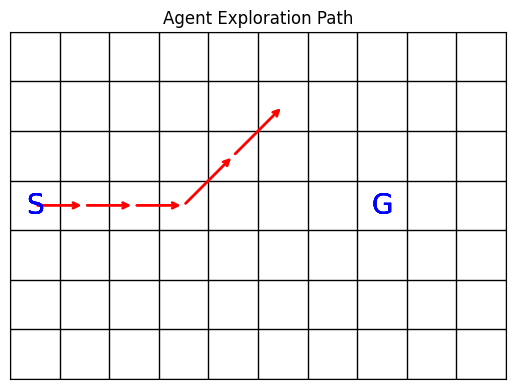

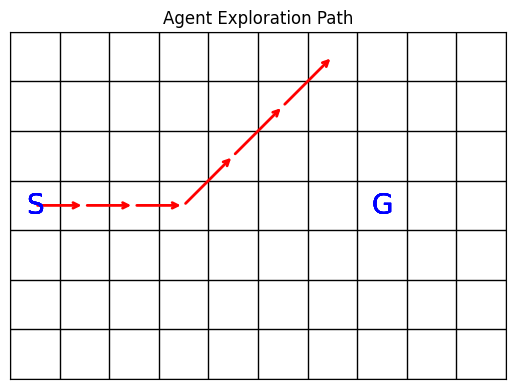

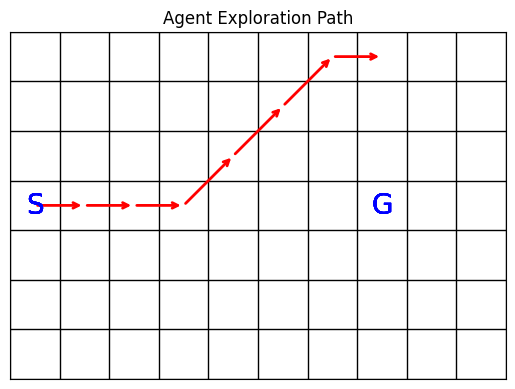

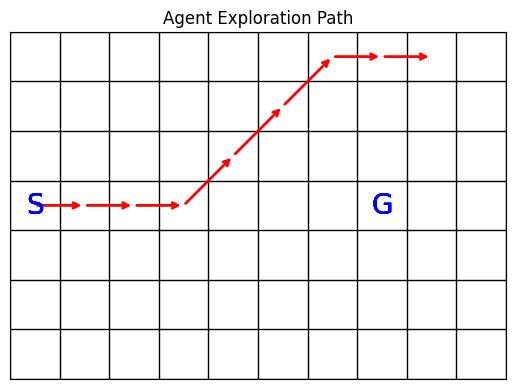

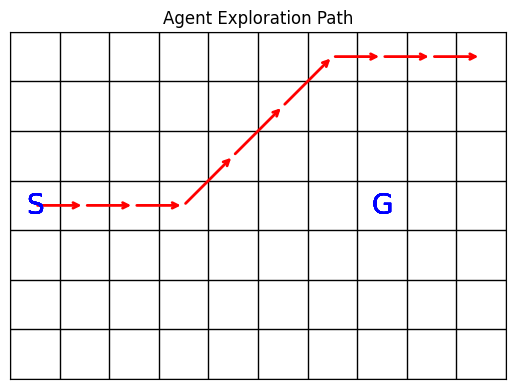

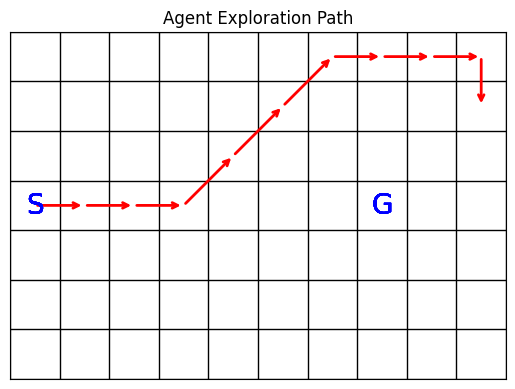

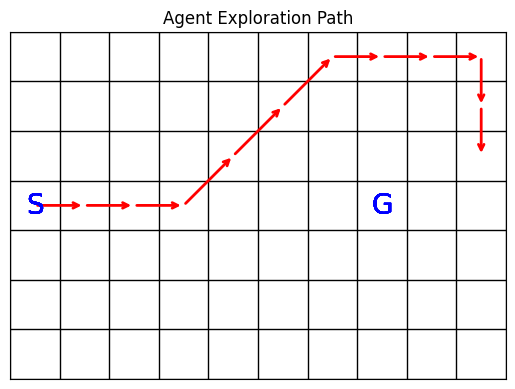

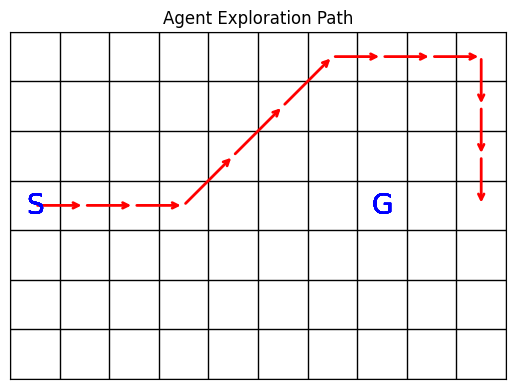

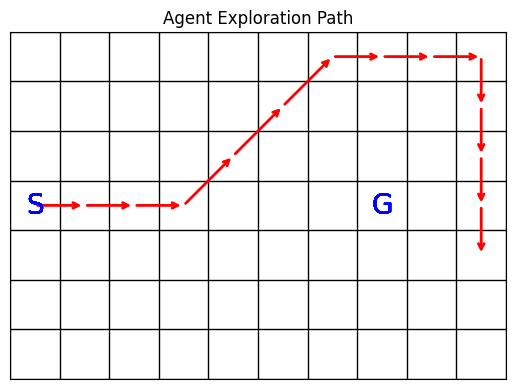

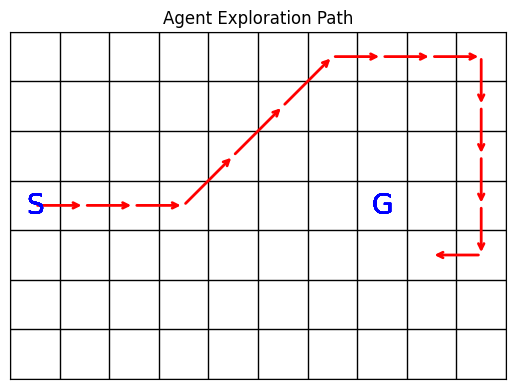

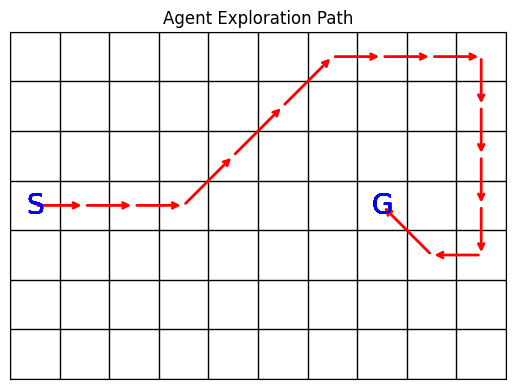

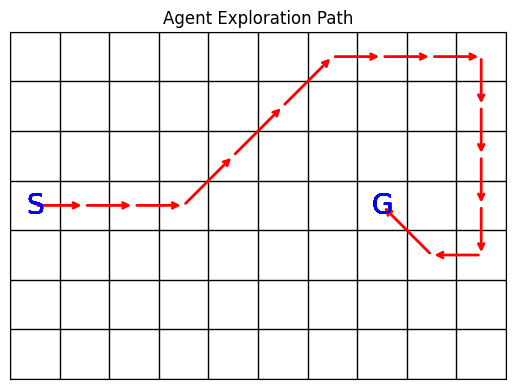

In [38]:
plot_episode(env, pi)

## Q-Learning: Off-policy TD Control

This method is defined by:

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma \operatorname{argmax}_a Q(S_{t+1}, a) - Q(S_t, A_t)]
$$

**Q-learning (off-policy TD control) for estimating $\pi \approx \pi_*$**

```text
Algorithm parameters: step size alpha in (0, 1], small eps > 0
Initialize Q(s, a), for all s in S, a in A(s), arbitrarily except that Q(terminal, ;) = 0

Loop for each episode:
    Initialize S
    Loop for each step of episode
        Choose A from S using policy derived from Q(e.g. eps-greedy)
        Take action A, observer R, S'
        Q(S, A) <- Q(S, A) + alpha[R + gamma * max_a Q(S', A) - Q(S, A)]
        S <- S'
    until S is terminal

### Example: Cliff Walking

In [39]:
env = gym.make('CliffWalking-v1', render_mode='rgb_array')

In [55]:
def policy(env, q, state, eps):
    n_actions = env.action_space.n
    prob = np.random.rand()

    if prob > eps:
        # Select best action
        best_action = np.argmax(q[state, :])
        return best_action

    # Selects a random action
    return np.random.choice(n_actions)

def sarsa(env, eps = 0.1, alpha = 0.5, gamma=1.0, num_episodes=500, render=False):

    n_state = env.observation_space.n
    n_actions = env.action_space.n

    q = np.zeros((n_state, n_actions))
    
    for _ in tqdm(range(num_episodes)):
        obs = env.reset()[0]
        done = False

        while not done:
            action = policy(env, q, obs, eps)

            next_obs, reward, done, _, _ = env.step(action)
            best_action = np.argmax(q[next_obs])
            td_error = reward + gamma*q[next_obs, best_action] - q[obs, action]

            q[obs, action] = q[obs, action] + alpha*td_error

            obs = next_obs

    pi = np.argmax(q, axis=1)

    return q, pi

def render_cliff_walking(fig, ax, state, prev_state):
    nrows, ncols = 4, 12
    start = (3, 0)
    goal = (3, 11)

    state = np.unravel_index(state, (nrows, ncols))
    prev_state = np.unravel_index(prev_state, (nrows, ncols))

    data = np.zeros((4, 12))
    data[3, 1:11] = -1

    ax.imshow(data, cmap='RdYlGn', alpha=0.1)

    ax.set_xticks(np.arange(ncols))
    ax.set_yticks(np.arange(nrows))

    ax.set_xticks(np.arange(-.5, ncols, 1), minor=True)
    ax.set_yticks(np.arange(-.5, nrows, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)

    ax.annotate("", xy=(state[1], state[0]),         # Arrow tip
                            xytext=(prev_state[1], prev_state[0]), # Arrow tail
                            arrowprops=dict(
                            arrowstyle="->", 
                            color="red", 
                            lw=2
                            # shrinkA=5, shrinkB=5 # Keeps arrow inside the cell
    ))

    ax.tick_params(which='both',
                bottom=False,
                left=False,
                labelbottom=False,
                labelleft=False
    )

    ax.text(start[1], start[0], 'S', va='center', ha='center', fontsize=20, color='blue')
    ax.text(goal[1], goal[0], 'G', va='center', ha='center', fontsize=20, color='blue')

    ax.set_title("Agent Exploration Path")

    display.display(fig)

def plot_episode(env, pi):

    fig, ax = plt.subplots()

    obs = env.reset()[0]
    done = False
        
    while not done: 
        action = pi[obs]

        next_obs, _, done, _, _ = env.step(action)

        render_cliff_walking(fig, ax, next_obs, obs)

        obs = next_obs

In [56]:
q, pi = sarsa(env, 0.1)

100%|██████████| 500/500 [00:00<00:00, 6787.21it/s]


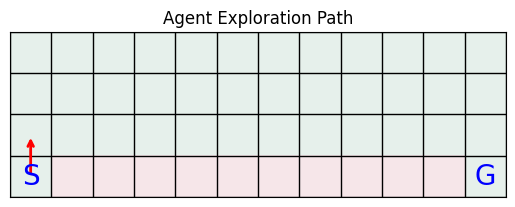

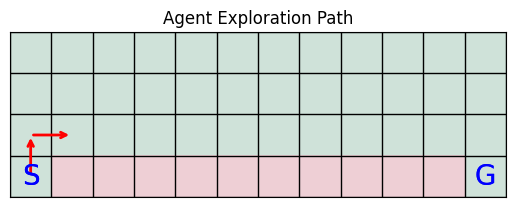

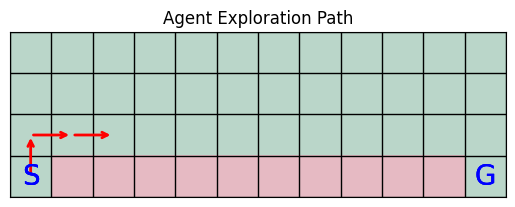

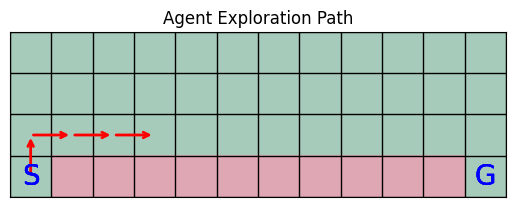

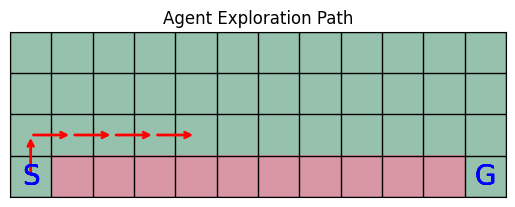

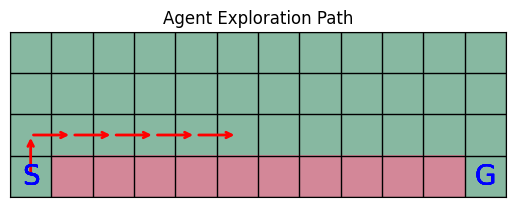

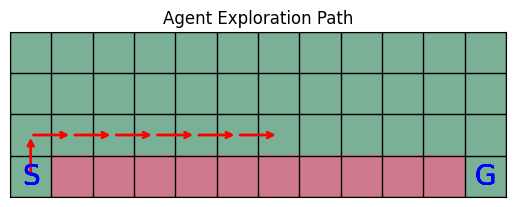

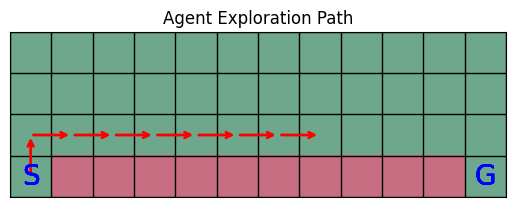

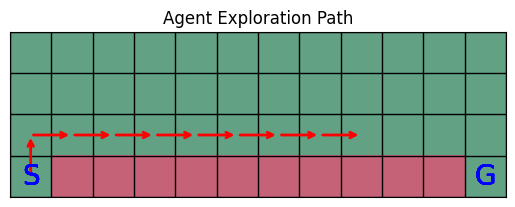

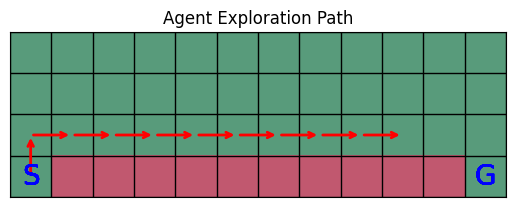

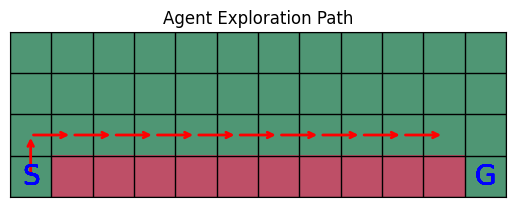

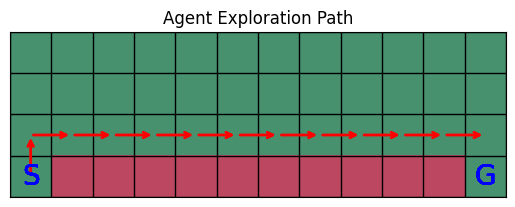

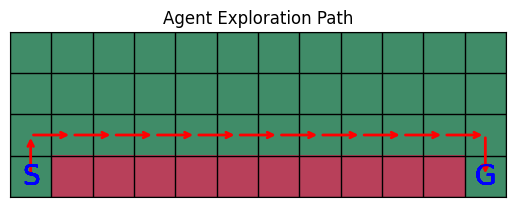

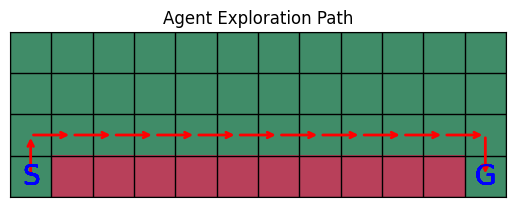

In [57]:
plot_episode(env, pi)

## Expected SARSA

Consider the learning algorithm that is just like Q-learning except that instead of the maximum over next state-action pairs it uses the expected value, taking into account how likely each action is under the current policy. That is, consider the algorithm with the update rule:

$$
Q(S_t, A_t) = Q(S_t, A_t) + \alpha [R_{t+1} + \gamma \sum_a \pi (a|S_{t+1})Q(S_{t+1, a})-Q(S_t, A_t)]
$$

Given the next state, $S_{t+1}$ this algorithm moves *deterministically* in the same direction as Sarsa moves in *expectation*, and accordingly it is called *Expected Sarsa*.

Expected Sarsa is more complex computationally than Sarsa, but, in return, it eliminates the variance due to the random selection of $A_{t+1}$. Given the same amount of experience we might expect it to perform slightly better than Sarsa, and indeed it generally does.

## Maximization Bias and Double Learning

All the control algorithms so far involve maximization in the construction of their target policies. In these algorithms, a maximum over estimated values is used implicitly as an estimate of the maximum value, which can lead to a significant positive bias. The maximum of the true values is zero, but the maximum of the estimates is positive, a positive bias. We call this *maximization bias*.

There are some algorithms that avoid maximization bias. In order to do so, consider a bandit case in which we have noisy estmates of the value of each of many action, obtained as sample averages of the rewards received on all the plays with each action. There will be a positive maximization bias if we use the maximum of the estimates as an estimate of the maximum true values.

Suppose we divided the plays in two sets and used them to learn two independent estimates, call them $Q_1(a)$ and $Q_2(a)$, each an estimate of the true value $q(a)$, for all $a \in \mathcal{A}$. We could then use one estimate, say $Q_1$, to determine the maximizing action $A^* = argmax_a Q_1(a)$, and the other, $Q_2$, to provide the estimate of its value, $Q_2(A^*) = Q_2(argmax_a Q_1 (a))$. This estimate will then be unbiased in the sense that $\mathbb{E}[Q_2(A^*)] = q(A^*)$. We can also repeat the process with the role of the two estimates reversed to yield a second unbiased estimate $Q_1(argmax_a Q_2)$. This is the idea of **double learning**.

The double learning algorithm for Q-learning, called Double Q-learning divides the time steps in two, perhaps by flipping a coin on each step. If the coin comes up heads, the update is:

$$
Q_1(S_t, A_t) \leftarrow Q_1(S_t, A_t) + \alpha[R_{t+1} + \gamma Q_2(S_{t+1}, \operatorname{argmax}_a Q_1(S_{t+1}, a)) - Q_1(S_t, A_t)]
$$

If the coin comes up tails, then the same update is done with $Q_1$ and $Q_2$ switched, so that $Q_2$ is updated.

Below is the algorithm for this Double Q-learning

**Double Q-learning, for estimating $Q_1 \approx Q_2 \approx q_*$**

```text
Algorithm parameters: step size alpha in (0, 1], small eps > 0
Initialize Q1(s, a) and Q2(s, a), for all s in S, a in A(s), such that Q(terminal, ;) = 0

Loop for each episode:
    Initialize S
    Loop for each step of episode:
        Choose A from S using the policy eps-greedy in Q1 + Q2
        Take action A, observe R, S'
        With 0.5 probability:
            Q1(S, A) <- Q1(S, A) + alpha(R + gamma Q2(S', argmax_a Q1(S', a)) - Q1(S, A))
        else:
            Q2(S, A) <- Q2(S, A) + alpha(R + gamma Q1(S', argmax_a Q2(S'a, a)) - Q2(S, a))
        S <- S'
    until S is terminal

## References

Sutton, R. S., & Barto, A. G. (2018). Reinforcement Learning: An Introduction (2nd ed.). MIT Press.